## 0. Import external libraries

In [ ]:
!pip install keras_unet_collection

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.9/67.9 kB 7.9 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from keras_unet_collection import models, losses

## 1. Preparing Dataset

### 1.1. Importing dataset


In [ ]:
# Descargamos el conjunto de datos en el almacenamiento temporal de Google Colab
!curl -L -o images.npz https://github.com/DivyanshuTak/Ultrasoud_Unet_Segmentation/raw/refs/heads/main/images.npz
!curl -L -o masks.npz https://github.com/DivyanshuTak/Ultrasoud_Unet_Segmentation/raw/refs/heads/main/masks.npz

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 9601k  100 9601k    0     0  9492k      0  0:00:01  0:00:01 --:--:-- 81.5M
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 92714  100 92714    0     0   189k      0 --:--:-- --:--:-- --:--:--  189k


### 1.2. Cleaning data


In [ ]:
# Load images
images = np.load("images.npz")["images"]
masks = np.load("masks.npz")["masks"]

# Removing unnecesary parts
images = images[:, 24:]
masks = masks[:, 24:]

# Convert to grayscale
images = images[:,:,:,0]

# Maybe need to shuffle images and convert mask to boolean values?
# AI generated code to improve the performance after tests
images = images / 255.0 # if rgb, convert that to a range from 0 to 1
masks = (masks > 0).astype("float32")

# Add pad to iamges and masks so they have a resolution of 320x320
def pad(x):
    return np.pad(x[..., None], ((0, 0), (22, 22), (10, 10), (0, 0)))

print(images.shape)
print(masks.shape)

(208, 276, 300)
(208, 276, 300)


Normalizing images size for the nn and shuffling data


In [ ]:
images = pad(images)
masks = pad(masks)

# Shuffling dataset
idx = np.random.permutation(len(images))
images = images[idx]
masks = masks[idx]

### 1.5. Dataset division




In [ ]:
# 80% training and 10% for val (will be assigned later)
X_train = images[:180]
y_train = masks[:180]

# Small dataset, 10%, aprox 28 images will be used for test at the end
X_test = images[180:]
y_test = masks[180:]

## 2. Neural Network architecture


In [ ]:
# Used AI for these functions
bce = tf.keras.losses.BinaryCrossentropy()

def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])

    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    denominator = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f)

    return (2.0 * intersection + smooth) / (denominator + smooth)

def iou_coef(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])

    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    union = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) - intersection

    return (intersection + smooth) / (union + smooth)

def dice_loss(y_true, y_pred):
    return 1.0 - dice_coef(y_true, y_pred)

def bce_dice_loss(y_true, y_pred):
    return bce(y_true, y_pred) + dice_loss(y_true, y_pred)

# dice_coef: Measures the overlap between the prediction and the actual mask. Ideal for segmentation with unbalanced classes.
# iou_coef: Similar to Dice but penalizes false positives and negatives more.
# bce_dice_loss: Combines Binary Crossentropy (good for convergence) with Dice Loss (good for segmentation accuracy).
# smooth: Avoids division by zero when there are no positive pixels.

# IoU stands for Intersection over Union. It calculates what proportion of the shared area between prediction and ground truth it represents relative to the total area covered by both masks.
# If there is no overlap, IoU is 0; if they coincide perfectly, it is 1.

In [ ]:
model = models.unet_3plus_2d(
    input_size=(320, 320, 1),
    n_labels=1,
    filter_num_down=[64, 128, 256, 512],
    output_activation="Sigmoid"
)

Automated hyper-parameter determination is applied with the following details:
----------
	Number of convolution filters after each full-scale skip connection: filter_num_skip = [64, 64, 64]
	Number of channels of full-scale aggregated feature maps: filter_num_aggregate = 256


## 3. Setting up the neural network

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=bce_dice_loss,
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="bin_acc"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        dice_coef,
        iou_coef
    ]
)

# model.compile(
#     optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
#     loss=bce_dice_loss,
#     metrics=[dice_coef, iou_coef, tf.keras.metrics.BinaryAccuracy(name="bin_acc")]
# )

Once the architecture of the Artificial Neural Network has been defined, we can visualize it along with the total number of parameters using the method`summary()`

In [ ]:
model.summary()

## 4. Training the neural network



In [ ]:
history = model.fit(X_train, y_train, batch_size=16, epochs=50, validation_split=0.1)

Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 143s 4s/step - bin_acc: 0.5737 - dice_coef: 0.2231 - iou_coef: 0.1265 - loss: 1.6510 - precision: 0.1401 - recall: 0.9647 - val_bin_acc: 0.0785 - val_dice_coef: 0.1264 - val_iou_coef: 0.0675 - val_loss: 1.5679 - val_precision: 0.0728 - val_recall: 1.0000
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 6s 533ms/step - bin_acc: 0.9328 - dice_coef: 0.3917 - iou_coef: 0.2456 - loss: 0.8996 - precision: 0.5180 - recall: 0.8764 - val_bin_acc: 0.8525 - val_dice_coef: 0.1267 - val_iou_coef: 0.0676 - val_loss: 1.5611 - val_precision: 0.2373 - val_recall: 0.4695
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 6s 533ms/step - bin_acc: 0.9644 - dice_coef: 0.5534 - iou_coef: 0.3846 - loss: 0.5856 - precision: 0.7104 - recall: 0.8475 - val_bin_acc: 0.9277 - val_dice_coef: 0.1267 - val_iou_coef: 0.0676 - val_loss: 1.5510 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 6s 533ms/step - bin_acc: 0.9726 - dice_coef: 0.6838 - iou_coef: 0.5220 - 

The variable ***history*** stores several important values:
* The model parameter values ​​after training
* The list of *epochs* performed
* A dictionary containing the error produced in each *epoch* in the training and validation dataset

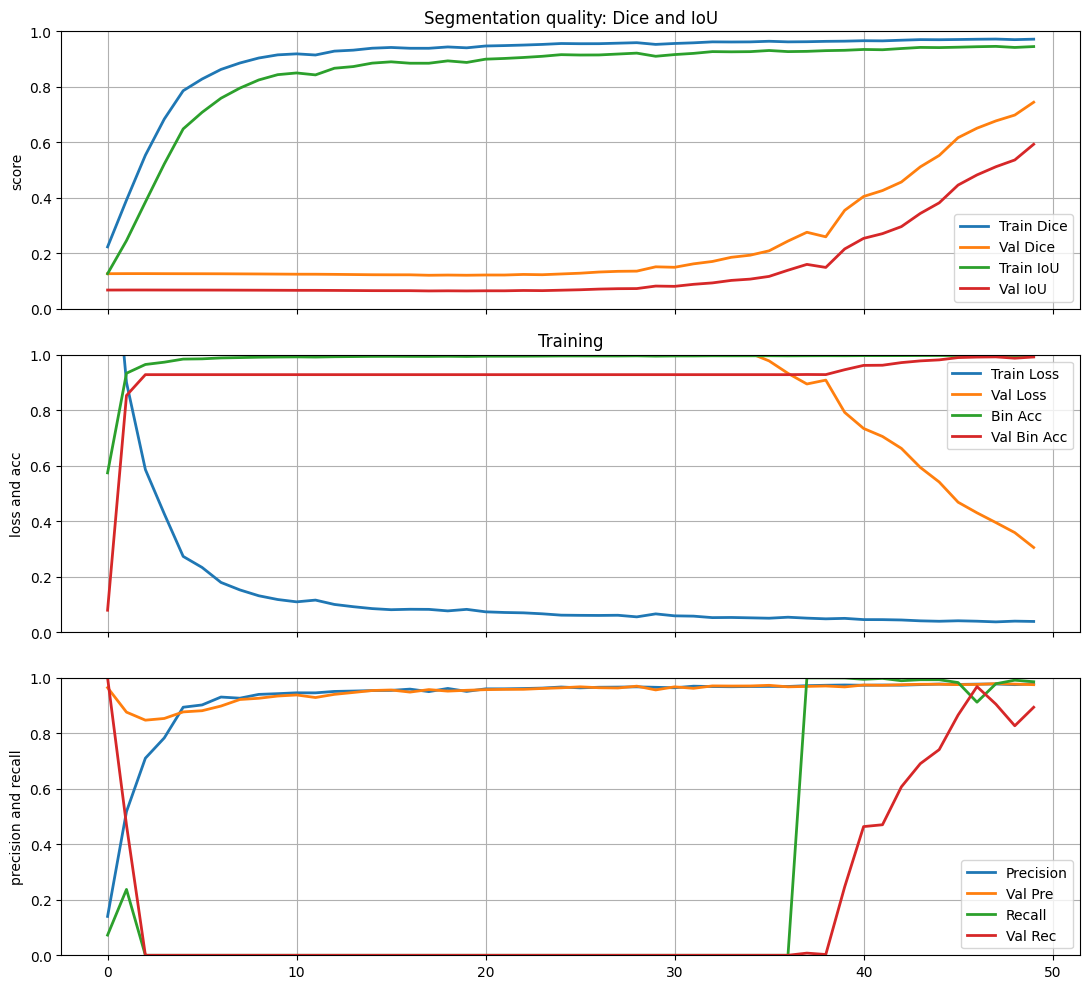

In [ ]:
# Now with trimmed Images and separated graph
hist_df = pd.DataFrame(history.history)
fig, axes = plt.subplots(3, 1, figsize=(11, 10), sharex=True)

seg_cols = ['dice_coef', 'val_dice_coef', 'iou_coef', 'val_iou_coef']
hist_df[seg_cols].plot(ax=axes[0], linewidth=2)

# Quality
axes[0].set_title("Segmentation quality: Dice and IoU")
axes[0].set_ylabel("score")
axes[0].set_ylim(0, 1.0)
axes[0].grid(True)
axes[0].legend([
    'Train Dice', 'Val Dice',
    'Train IoU', 'Val IoU'
])

# Training
loss_cols = ['loss', 'val_loss', 'bin_acc', 'val_bin_acc']
hist_df[loss_cols].plot(ax=axes[1], linewidth=2)

axes[1].set_title("Training")
axes[1].set_ylabel("loss and acc")
axes[1].set_ylim(0, 1.0)
axes[1].set_xlabel("epochs")
axes[1].grid(True)
axes[1].legend(['Train Loss', 'Val Loss', 'Bin Acc', 'Val Bin Acc'])


# precision recall
pre_call = ['precision', 'recall', 'val_precision', 'val_recall']
hist_df[pre_call].plot(ax=axes[2], linewidth=2)

axes[2].set_ylabel("precision and recall")
axes[2].set_ylim(0, 1.0)
axes[2].grid(True)
axes[2].legend([
    'Precision', 'Val Pre',
    'Recall', 'Val Rec'
])


plt.tight_layout()
plt.show()

## 5. Save model in disk


In [ ]:
# Save the model in disk
from google.colab import drive
drive.mount('/content/drive')

model.save("/content/drive/MyDrive/IMPACT/models")

In [ ]:
# Load model in disk
model_disk = keras.models.load_model("/content/drive/MyDrive/IMPACT/models")

## 6. Predicting new examples

In [ ]:
# Evaluate on test dataset - evaluate does the same as predict, but now with metrics so we can take conclusions
evaluation_result = model.evaluate(X_test, y_test)

# Print metrics of evaluation (example loss and accuracy)
print("Loss:", evaluation_result[0])
print("Accuracy:", evaluation_result[1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 36s 36s/step - bin_acc: 0.9921 - dice_coef: 0.7473 - iou_coef: 0.5966 - loss: 0.2975 - precision: 0.9840 - recall: 0.9015
Loss: 0.29753628373146057
Accuracy: 0.9921002984046936


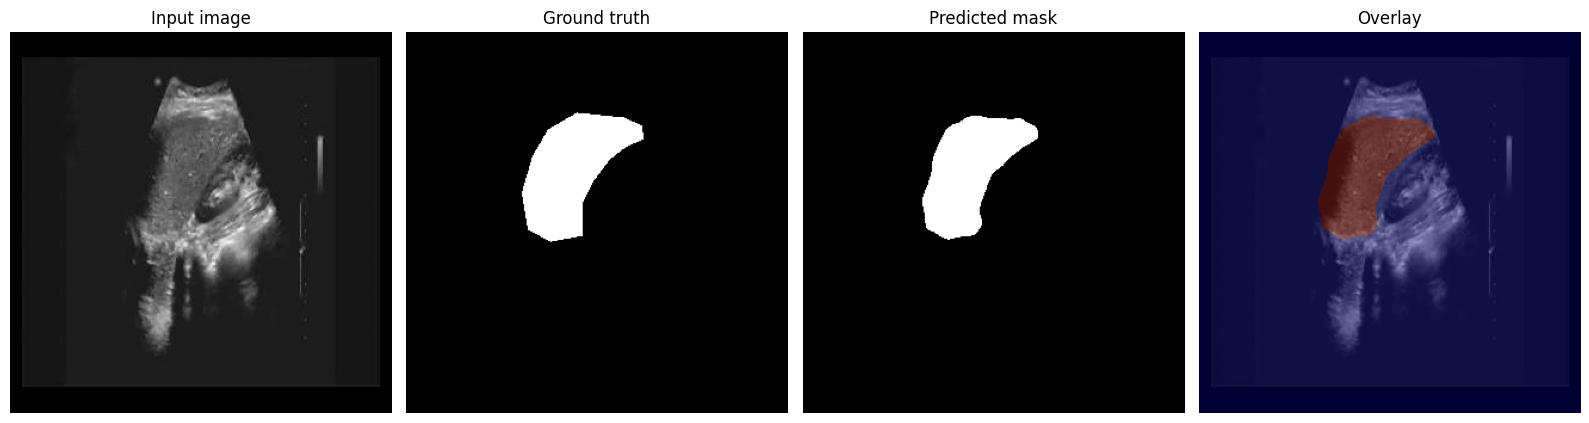

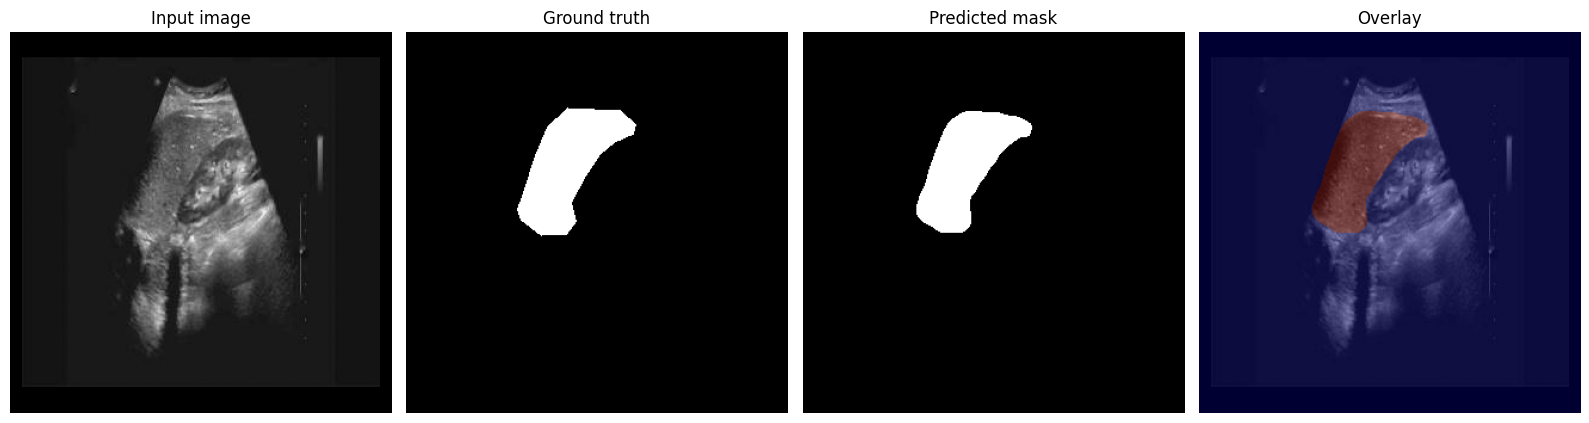

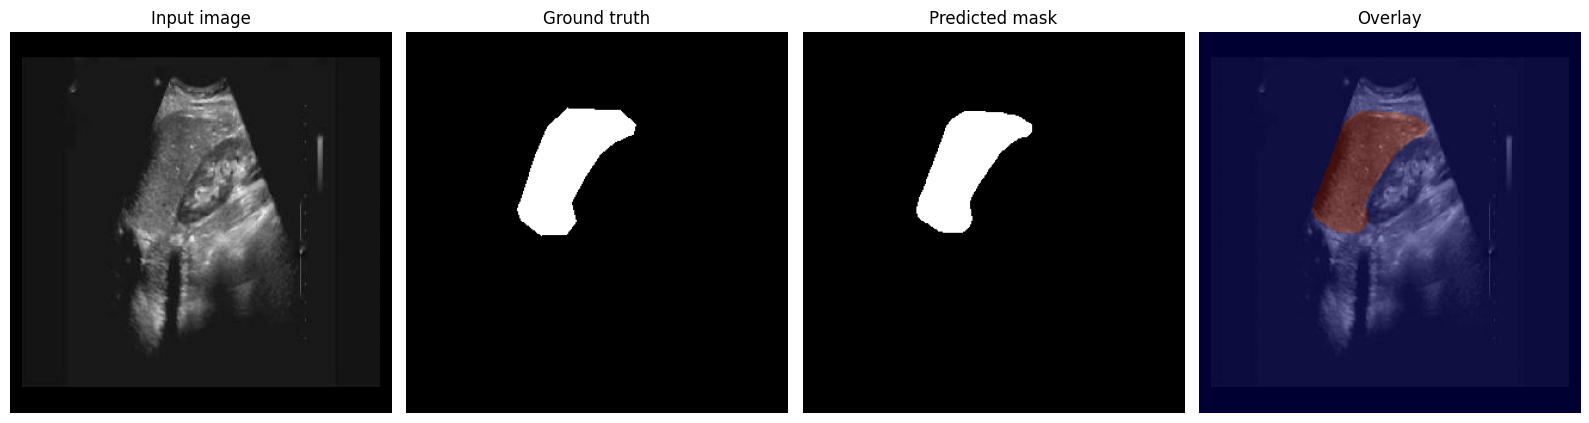

In [ ]:
for i in range(3):
    idx = np.random.randint(0, len(X_test))
    image = X_test[idx]
    mask = y_test[idx]

    pred = model.predict(np.expand_dims(image, axis=0), verbose=0)
    prediction = pred[0]                    # quita dimensión batch
    prediction_bin = (prediction > 0.5).astype(np.uint8) # Converts the probabilistic output of the model into a binary mask of 0s and 1s.

    fig, axs = plt.subplots(1, 4, figsize=(16, 6))

    axs[0].imshow(image.squeeze(), cmap="gray")
    axs[0].set_title("Input image")
    axs[0].axis("off")

    axs[1].imshow(mask.squeeze(), cmap="gray")
    axs[1].set_title("Ground truth")
    axs[1].axis("off")

    axs[2].imshow(prediction_bin.squeeze(), cmap="gray")
    axs[2].set_title("Predicted mask")
    axs[2].axis("off")

    axs[3].imshow(image.squeeze(), cmap="gray")
    axs[3].imshow(prediction_bin.squeeze(), cmap="jet", alpha=0.4)
    axs[3].set_title("Overlay")
    axs[3].axis("off")

    plt.tight_layout()
    plt.show()
